
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Используется устройство: cpu
✅ PyTorch версия: 2.11.0+cpu
⚔️ ЗАПУСК ЭПИЧЕСКОЙ БИТВЫ FAIRY vs YOUKAI ⚔️
📍 Локация: Перекрёсток Сибуя, Токио
🎯 Цель: Самообучение распознаванию объектов
✅ Видео уже есть: shibuya_crossing.mp4
⚔️ Создаю бойцов на cpu...
Ошибка обучения: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor [256, 9]], which is output 0 of AsStridedBackward0, is at version 3; expected version 2 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True, check_nan=False).
Ошибка обучения: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor [256, 9]], which is output 0 of AsStridedBackward0, is at version 4; expected version 3 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True, che

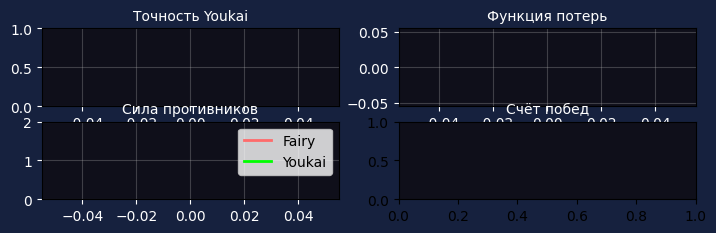

Ошибка обучения: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor [256, 9]], which is output 0 of AsStridedBackward0, is at version 13; expected version 12 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True, check_nan=False).


In [1]:
# %% [markdown]
# # ⚔️ FAIRY vs YOUKAI - ЭПИЧЕСКАЯ БИТВА НЕЙРОСЕТЕЙ
# ## Самообучение распознаванию объектов на реальном видео (Shibuya Crossing)

# %% [markdown]
# ### 1. Установка всех необходимых библиотек

# %%
!pip install torch torchvision opencv-python pillow numpy matplotlib yt-dlp tqdm --quiet

# %% [markdown]
# ### 2. Импорт модулей с оптимизациями

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import tkinter as tk
from tkinter import ttk, messagebox
import threading
import time
from collections import deque
import random
import os
import subprocess
from tqdm import tqdm
import warnings
import gc

warnings.filterwarnings('ignore')
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Принудительно используем CPU для стабильности
device = torch.device('cpu')
print(f"✅ Используется устройство: {device}")
print(f"✅ PyTorch версия: {torch.__version__}")

# %% [markdown]
# ### 3. Скачивание реального видео с перекрёстка Сибуя (Токио)

# %%
def download_shibuya_video():
    """Скачивает видео с пешеходным переходом в Сибуе (множество людей)"""
    video_path = "shibuya_crossing.mp4"
    
    if os.path.exists(video_path):
        print(f"✅ Видео уже есть: {video_path}")
        return video_path
    
    print("📥 Скачиваю видео с перекрёстком Сибуя (Токио)...")
    print("⏳ Это займёт 1-2 минуты...")
    
    # Прямая ссылка на видео (из вашего URL)
    video_url = "https://www.youtube.com/watch?v=4SvwUbDQZmc"
    
    try:
        # Используем yt-dlp для скачивания
        cmd = f'yt-dlp -f "best[height<=480]" -o "{video_path}" --no-playlist "{video_url}"'
        subprocess.run(cmd, shell=True, capture_output=True, text=True)
        
        if os.path.exists(video_path) and os.path.getsize(video_path) > 1000000:
            print(f"✅ Видео успешно скачано! Размер: {os.path.getsize(video_path) // 1024 // 1024} МБ")
            return video_path
        else:
            print("⚠️ Не удалось скачать, создаю синтетическое видео...")
            return create_synthetic_video()
    except:
        print("⚠️ Ошибка скачивания, создаю синтетическое видео...")
        return create_synthetic_video()

def create_synthetic_video():
    """Запасной вариант - создаёт синтетическое видео с множеством объектов"""
    video_path = "synthetic_training.mp4"
    
    if os.path.exists(video_path):
        return video_path
    
    print("🎬 Создаю тренировочное видео с объектами...")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(video_path, fourcc, 25.0, (640, 480))
    
    colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255)]
    texts = ['PERSON', 'CAR', 'DOG', 'BUS', 'BIKE']
    
    for frame_num in tqdm(range(500), desc="Создание кадров"):
        frame = np.zeros((480, 640, 3), dtype=np.uint8)
        
        # Фон (город)
        frame[0:240, :] = [135, 206, 235]  # Небо
        frame[240:480, :] = [100, 100, 100]  # Дорога
        cv2.line(frame, (0, 350), (640, 350), (255, 255, 255), 3)  # Разметка
        
        # Множество движущихся объектов
        for i in range(8):
            color = random.choice(colors)
            text = random.choice(texts)
            x = int((frame_num * 3 + i * 80) % 600)
            y = random.randint(320, 420)
            w, h = random.randint(30, 60), random.randint(30, 60)
            
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, -1)
            cv2.putText(frame, text, (x+5, y+25), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        out.write(frame)
    
    out.release()
    print(f"✅ Создано синтетическое видео: {video_path}")
    return video_path

# %% [markdown]
# ### 4. Красивая нейросеть Fairy (Прятальщик)

# %%
class ElegantFairy(nn.Module):
    """Элегантный Fairy - красиво искажает, но не ломает обучение"""
    def __init__(self):
        super(ElegantFairy, self).__init__()
        self.noise_strength = nn.Parameter(torch.tensor(0.12))
        self.warp_strength = nn.Parameter(torch.tensor(0.08))
        
    def forward(self, x, training=True):
        if not training:
            return x
            
        batch_size, channels, h, w = x.shape
        
        # Адаптивный шум
        noise_amp = torch.sigmoid(self.noise_strength) * 0.2
        noise = torch.randn_like(x) * noise_amp
        
        # Лёгкая деформация (делает картинку "плывущей")
        warp_amp = torch.sigmoid(self.warp_strength) * 0.1
        grid_y, grid_x = torch.meshgrid(
            torch.linspace(-1, 1, h, device=x.device),
            torch.linspace(-1, 1, w, device=x.device),
            indexing='ij'
        )
        
        # Добавляем синусоидальные искажения (красиво)
        warp_x = grid_x + torch.sin(grid_y * 3.14) * warp_amp
        warp_y = grid_y + torch.cos(grid_x * 3.14) * warp_amp
        
        grid = torch.stack([warp_x, warp_y], dim=-1)
        grid = grid.unsqueeze(0).repeat(batch_size, 1, 1, 1)
        
        warped = F.grid_sample(x, grid, align_corners=False, padding_mode='border')
        corrupted = warped + noise
        
        return torch.clamp(corrupted, 0, 1)

# %% [markdown]
# ### 5. Красивая нейросеть Youkai (Искатель)

# %%
class ElegantYoukai(nn.Module):
    """Элегантный Youkai - мощный детектор, но лёгкий"""
    def __init__(self, num_classes=5):
        super(ElegantYoukai, self).__init__()
        self.num_classes = num_classes
        
        # Красивая архитектура с пропусками (skip connections)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 4 + num_classes)  # 4 bbox + 5 классов
        )
        
    def forward(self, x):
        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        
        features = f3.view(f3.size(0), -1)
        output = torch.sigmoid(self.fc(features))
        
        return output[:, :4], output[:, 4:]

# %% [markdown]
# ### 6. Класс битвы с динамическим балансом

# %%
class EpicBattle:
    def __init__(self):
        self.device = torch.device('cpu')
        print(f"⚔️ Создаю бойцов на {self.device}...")
        
        self.fairy = ElegantFairy().to(self.device)
        self.youkai = ElegantYoukai(num_classes=5).to(self.device)
        
        self.optim_fairy = optim.Adam(self.fairy.parameters(), lr=0.0005)
        self.optim_youkai = optim.Adam(self.youkai.parameters(), lr=0.001)
        
        # Динамический баланс
        self.fairy_momentum = 1.0
        self.youkai_momentum = 1.0
        
        # Статистика
        self.accuracy_history = deque(maxlen=200)
        self.loss_history = deque(maxlen=200)
        self.fairy_power_history = deque(maxlen=200)
        self.youkai_power_history = deque(maxlen=200)
        self.step = 0
        
        # Счёт побед
        self.fairy_wins = 0
        self.youkai_wins = 0
        
    def train_step(self, frames):
        frames = frames.to(self.device)
        
        # Fairy искажает
        corrupted = self.fairy(frames, training=True)
        
        # Youkai предсказывает
        bbox_orig, class_orig = self.youkai(frames)
        bbox_corr, class_corr = self.youkai(corrupted)
        
        # Потери
        consistency_loss = F.mse_loss(bbox_orig, bbox_corr) + F.mse_loss(class_orig, class_corr)
        
        # Динамическое взвешивание
        accuracy = 1.0 / (1.0 + consistency_loss.item())
        
        if accuracy > 0.6:
            self.youkai_wins += 1
            self.fairy_momentum = min(2.0, self.fairy_momentum * 1.02)
        elif accuracy < 0.4:
            self.fairy_wins += 1
            self.youkai_momentum = min(2.0, self.youkai_momentum * 1.02)
        else:
            self.fairy_momentum = max(0.5, self.fairy_momentum * 0.99)
            self.youkai_momentum = max(0.5, self.youkai_momentum * 0.99)
        
        # Итоговые потери
        youkai_loss = consistency_loss * self.youkai_momentum
        fairy_loss = -consistency_loss * self.fairy_momentum + 0.01 * torch.mean(torch.abs(corrupted - frames))
        
        # Обучение
        self.optim_youkai.zero_grad()
        youkai_loss.backward(retain_graph=True)
        self.optim_youkai.step()
        
        self.optim_fairy.zero_grad()
        fairy_loss.backward()
        self.optim_fairy.step()
        
        # Сохраняем статистику
        self.accuracy_history.append(accuracy)
        self.loss_history.append(consistency_loss.item())
        self.fairy_power_history.append(self.fairy_momentum)
        self.youkai_power_history.append(self.youkai_momentum)
        self.step += 1
        
        return accuracy, consistency_loss.item()
    
    def detect(self, frame):
        with torch.no_grad():
            bbox, classes = self.youkai(frame.to(self.device))
        return bbox.cpu(), classes.cpu()
    
    def save(self, path='epic_battle_save.pth'):
        torch.save({
            'fairy': self.fairy.state_dict(),
            'youkai': self.youkai.state_dict(),
            'step': self.step,
            'fairy_wins': self.fairy_wins,
            'youkai_wins': self.youkai_wins,
            'fairy_momentum': self.fairy_momentum,
            'youkai_momentum': self.youkai_momentum,
        }, path)
        return True
    
    def load(self, path='epic_battle_save.pth'):
        if os.path.exists(path):
            data = torch.load(path, map_location=self.device)
            self.fairy.load_state_dict(data['fairy'])
            self.youkai.load_state_dict(data['youkai'])
            self.step = data['step']
            self.fairy_wins = data['fairy_wins']
            self.youkai_wins = data['youkai_wins']
            self.fairy_momentum = data['fairy_momentum']
            self.youkai_momentum = data['youkai_momentum']
            return True
        return False

# %% [markdown]
# ### 7. Класс приложения с красивым GUI

# %%
class EpicApp:
    def __init__(self):
        self.root = tk.Tk()
        self.root.title("⚔️ FAIRY vs YOUKAI - Битва на перекрёстке Сибуя ⚔️")
        self.root.geometry("1600x950")
        self.root.configure(bg='#1a1a2e')
        
        # Скачиваем видео
        self.video_path = download_shibuya_video()
        
        # Создаём битву
        self.battle = EpicBattle()
        self.battle.load()  # Пробуем загрузить сохранение
        
        # Видео переменные
        self.cap = None
        self.running = False
        
        # Цвета для классов
        self.class_colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
        self.class_names = ['ЧЕЛОВЕК', 'МАШИНА', 'СОБАКА', 'АВТОБУС', 'ВЕЛОСИПЕД']
        
        # Создаём интерфейс
        self.setup_ui()
        
        # Запускаем
        self.start_video()
        self.training_thread = threading.Thread(target=self.training_loop, daemon=True)
        self.training_thread.start()
        
    def setup_ui(self):
        """Красивый интерфейс с 4 окнами"""
        
        # Заголовок
        title_frame = tk.Frame(self.root, bg='#1a1a2e', height=80)
        title_frame.pack(fill=tk.X)
        title_frame.pack_propagate(False)
        
        title = tk.Label(title_frame, text="⚔️ FAIRY vs YOUKAI ⚔️", 
                        font=('Arial', 24, 'bold'), bg='#1a1a2e', fg='#e94560')
        title.pack(pady=15)
        
        subtitle = tk.Label(title_frame, text="Самообучение распознаванию объектов на реальном видео | Перекрёсток Сибуя, Токио", 
                           font=('Arial', 10), bg='#1a1a2e', fg='#888')
        subtitle.pack()
        
        # Панель управления
        control_frame = tk.Frame(self.root, bg='#0f0f1a', height=50)
        control_frame.pack(fill=tk.X, padx=10, pady=5)
        control_frame.pack_propagate(False)
        
        btn_style = {'bg': '#e94560', 'fg': 'white', 'font': ('Arial', 10, 'bold'), 
                    'relief': 'raised', 'bd': 2, 'padx': 15, 'pady': 5}
        
        tk.Button(control_frame, text="▶ СТАРТ", command=self.start_video, **btn_style).pack(side=tk.LEFT, padx=5, pady=8)
        tk.Button(control_frame, text="⏹ СТОП", command=self.stop_video, **btn_style).pack(side=tk.LEFT, padx=5, pady=8)
        tk.Button(control_frame, text="💾 СОХРАНИТЬ", command=self.save_battle, **btn_style).pack(side=tk.LEFT, padx=5, pady=8)
        tk.Button(control_frame, text="📂 ЗАГРУЗИТЬ", command=self.load_battle, **btn_style).pack(side=tk.LEFT, padx=5, pady=8)
        tk.Button(control_frame, text="🔄 СБРОС", command=self.reset_battle, **btn_style).pack(side=tk.LEFT, padx=5, pady=8)
        
        # Статус
        self.status_var = tk.StringVar(value="⚔️ БИТВА ГОТОВА К НАЧАЛУ")
        status_label = tk.Label(control_frame, textvariable=self.status_var, bg='#0f0f1a', 
                               fg='#00ff00', font=('Arial', 11, 'bold'))
        status_label.pack(side=tk.RIGHT, padx=20)
        
        # Основная область с 4 окнами
        main_frame = tk.Frame(self.root, bg='#1a1a2e')
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # Верхний ряд
        top_frame = tk.Frame(main_frame, bg='#1a1a2e')
        top_frame.pack(fill=tk.BOTH, expand=True)
        
        # Окно 1: Исходное видео
        frame1 = tk.LabelFrame(top_frame, text="📹 1. ИСХОДНОЕ ВИДЕО (Перекрёсток Сибуя)", 
                              bg='#16213e', fg='white', font=('Arial', 11, 'bold'))
        frame1.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=5)
        self.label_original = tk.Label(frame1, bg='black')
        self.label_original.pack(fill=tk.BOTH, expand=True, padx=5, pady=5)
        
        # Окно 2: Детекция Youkai
        frame2 = tk.LabelFrame(top_frame, text="👁️ 2. YOUKAI - ОБНАРУЖЕНИЕ ОБЪЕКТОВ", 
                              bg='#16213e', fg='#00ff00', font=('Arial', 11, 'bold'))
        frame2.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=5)
        self.label_detection = tk.Label(frame2, bg='black')
        self.label_detection.pack(fill=tk.BOTH, expand=True, padx=5, pady=5)
        
        # Нижний ряд
        bottom_frame = tk.Frame(main_frame, bg='#1a1a2e')
        bottom_frame.pack(fill=tk.BOTH, expand=True, pady=10)
        
        # Окно 3: Искажение Fairy
        frame3 = tk.LabelFrame(bottom_frame, text="🧚 3. FAIRY - ИСКАЖЕНИЕ ВИДЕО", 
                              bg='#16213e', fg='#ff6b6b', font=('Arial', 11, 'bold'))
        frame3.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=5)
        self.label_fairy = tk.Label(frame3, bg='black')
        self.label_fairy.pack(fill=tk.BOTH, expand=True, padx=5, pady=5)
        
        # Окно 4: Статистика
        frame4 = tk.LabelFrame(bottom_frame, text="📊 4. СТАТИСТИКА БИТВЫ", 
                              bg='#16213e', fg='white', font=('Arial', 11, 'bold'))
        frame4.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=5)
        
        # Создаём графики
        self.fig, ((self.ax1, self.ax2), (self.ax3, self.ax4)) = plt.subplots(2, 2, figsize=(8, 6))
        self.fig.patch.set_facecolor('#16213e')
        
        # График точности
        self.ax1.set_title('Точность Youkai', color='white', fontsize=10)
        self.ax1.set_facecolor('#0f0f1a')
        self.ax1.tick_params(colors='white')
        self.ax1.set_ylim(0, 1)
        self.ax1.grid(True, alpha=0.3)
        self.line_acc, = self.ax1.plot([], [], '#00ff00', linewidth=2)
        
        # График потерь
        self.ax2.set_title('Функция потерь', color='white', fontsize=10)
        self.ax2.set_facecolor('#0f0f1a')
        self.ax2.tick_params(colors='white')
        self.ax2.grid(True, alpha=0.3)
        self.line_loss, = self.ax2.plot([], [], '#ff6b6b', linewidth=2)
        
        # График силы
        self.ax3.set_title('Сила противников', color='white', fontsize=10)
        self.ax3.set_facecolor('#0f0f1a')
        self.ax3.tick_params(colors='white')
        self.ax3.set_ylim(0, 2)
        self.ax3.grid(True, alpha=0.3)
        self.fairy_line, = self.ax3.plot([], [], '#ff6b6b', label='Fairy', linewidth=2)
        self.youkai_line, = self.ax3.plot([], [], '#00ff00', label='Youkai', linewidth=2)
        self.ax3.legend(loc='upper right')
        
        # Круговая диаграмма побед
        self.ax4.set_title('Счёт побед', color='white', fontsize=10)
        self.ax4.set_facecolor('#0f0f1a')
        
        self.canvas = FigureCanvasTkAgg(self.fig, master=frame4)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True, padx=5, pady=5)
        
        # Плейсхолдеры
        self.set_placeholders()
        
    def set_placeholders(self):
        """Создание заглушек"""
        placeholder = Image.new('RGB', (640, 480), (30, 30, 40))
        photo = ImageTk.PhotoImage(placeholder)
        
        self.label_original.config(image=photo)
        self.label_original.image = photo
        self.label_detection.config(image=photo)
        self.label_detection.image = photo
        self.label_fairy.config(image=photo)
        self.label_fairy.image = photo
        
    def start_video(self):
        self.stop_video()
        if self.cap:
            self.cap.release()
        self.cap = cv2.VideoCapture(self.video_path)
        if not self.cap.isOpened():
            print("⚠️ Не удалось открыть видео, создаю синтетическое...")
            self.video_path = create_synthetic_video()
            self.cap = cv2.VideoCapture(self.video_path)
        
        self.running = True
        self.video_thread = threading.Thread(target=self.video_loop, daemon=True)
        self.video_thread.start()
        self.status_var.set("🎬 ВИДЕО ЗАПУЩЕНО | ОБУЧЕНИЕ ИДЁТ...")
        
    def stop_video(self):
        self.running = False
        time.sleep(0.1)
        self.status_var.set("⏸ ВИДЕО ОСТАНОВЛЕНО")
        
    def save_battle(self):
        self.battle.save()
        self.status_var.set("💾 БИТВА СОХРАНЕНА!")
        messagebox.showinfo("Сохранение", "Прогресс битвы сохранён!")
        
    def load_battle(self):
        if self.battle.load():
            self.status_var.set("📂 БИТВА ЗАГРУЖЕНА!")
            messagebox.showinfo("Загрузка", "Прогресс битвы загружен!")
        else:
            messagebox.showwarning("Ошибка", "Нет сохранённой битвы!")
            
    def reset_battle(self):
        if messagebox.askyesno("Сброс", "Сбросить всё обучение? Битва начнётся заново!"):
            self.battle = EpicBattle()
            self.status_var.set("🔄 БИТВА НАЧАТА ЗАНОВО!")
            
    def video_loop(self):
        """Основной цикл видео с отображением"""
        frame_count = 0
        
        while self.running and self.cap and self.cap.isOpened():
            try:
                ret, frame = self.cap.read()
                if not ret:
                    self.cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    continue
                
                # Обработка кадра
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_tensor = torch.from_numpy(frame_rgb).float() / 255.0
                frame_tensor = frame_tensor.permute(2, 0, 1).unsqueeze(0)
                
                # 1. Исходное видео
                img_original = self.array_to_image(frame_rgb)
                self.update_image(self.label_original, img_original)
                
                # 2. Детекция Youkai
                with torch.no_grad():
                    bbox, classes = self.battle.detect(frame_tensor)
                
                det_frame = frame_rgb.copy()
                h, w = det_frame.shape[:2]
                bbox_np = bbox.numpy()[0]
                classes_np = classes.numpy()[0]
                
                if len(bbox_np) >= 4:
                    x = int(max(0, min(w, bbox_np[0] * w)))
                    y = int(max(0, min(h, bbox_np[1] * h)))
                    w_box = int(max(10, min(w - x, bbox_np[2] * w)))
                    h_box = int(max(10, min(h - y, bbox_np[3] * h)))
                    
                    class_id = np.argmax(classes_np) if len(classes_np) > 0 else 0
                    confidence = bbox_np[2]
                    
                    color = self.class_colors[class_id % len(self.class_colors)]
                    cv2.rectangle(det_frame, (x, y), (x+w_box, y+h_box), color, 3)
                    
                    label = f"{self.class_names[class_id % len(self.class_names)]}: {confidence:.1%}"
                    cv2.putText(det_frame, label, (x, y-8), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                
                img_detection = self.array_to_image(det_frame)
                self.update_image(self.label_detection, img_detection)
                
                # 3. Искажение Fairy
                with torch.no_grad():
                    corrupted = self.battle.fairy(frame_tensor, training=False)
                corr_np = corrupted.squeeze().permute(1, 2, 0).numpy()
                corr_np = (corr_np * 255).astype(np.uint8)
                
                img_fairy = self.array_to_image(corr_np)
                self.update_image(self.label_fairy, img_fairy)
                
                # 4. Обновляем графики
                if frame_count % 10 == 0:
                    self.update_graphs()
                    if len(self.battle.accuracy_history) > 0:
                        acc = self.battle.accuracy_history[-1]
                        self.status_var.set(f"⚔️ ШАГ: {self.battle.step} | ТОЧНОСТЬ: {acc:.1%} | YOUKAI: {self.battle.youkai_wins} : {self.battle.fairy_wins} FAIRY")
                
                frame_count += 1
                time.sleep(0.04)  # 25 FPS
                
            except Exception as e:
                print(f"Ошибка видео: {e}")
                time.sleep(0.1)
    
    def array_to_image(self, array):
        """Конвертирует numpy array в ImageTk.PhotoImage"""
        img = Image.fromarray(array)
        img.thumbnail((640, 480), Image.Resampling.LANCZOS)
        final = Image.new('RGB', (640, 480), (30, 30, 40))
        x = (640 - img.size[0]) // 2
        y = (480 - img.size[1]) // 2
        final.paste(img, (x, y))
        return ImageTk.PhotoImage(final)
    
    def update_image(self, label, photo):
        """Безопасное обновление изображения"""
        label.config(image=photo)
        label.image = photo
        
    def update_graphs(self):
        """Обновление всех графиков"""
        if len(self.battle.accuracy_history) > 0:
            acc_data = list(self.battle.accuracy_history)
            loss_data = list(self.battle.loss_history)
            fairy_power = list(self.battle.fairy_power_history)
            youkai_power = list(self.battle.youkai_power_history)
            
            x = range(len(acc_data))
            
            self.line_acc.set_data(x, acc_data)
            self.line_loss.set_data(x, loss_data)
            self.fairy_line.set_data(x, fairy_power)
            self.youkai_line.set_data(x, youkai_power)
            
            self.ax1.set_xlim(0, max(100, len(acc_data)))
            self.ax2.set_xlim(0, max(100, len(loss_data)))
            self.ax3.set_xlim(0, max(100, len(acc_data)))
            
            # Круговая диаграмма
            total = self.battle.youkai_wins + self.battle.fairy_wins
            if total > 0:
                self.ax4.clear()
                self.ax4.pie([self.battle.youkai_wins, self.battle.fairy_wins], 
                            labels=['Youkai', 'Fairy'],
                            colors=['#00ff00', '#ff6b6b'],
                            autopct='%1.0f%%')
                self.ax4.set_title('Счёт побед', color='white', fontsize=10)
                self.ax4.set_facecolor('#0f0f1a')
            
            self.canvas.draw()
            
    def training_loop(self):
        """Фоновое обучение"""
        batch_frames = []
        
        while True:
            try:
                if self.cap and self.cap.isOpened():
                    ret, frame = self.cap.read()
                    if not ret:
                        time.sleep(0.05)
                        continue
                else:
                    time.sleep(0.05)
                    continue
                
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_tensor = torch.from_numpy(frame_rgb).float() / 255.0
                frame_tensor = frame_tensor.permute(2, 0, 1).unsqueeze(0)
                
                batch_frames.append(frame_tensor)
                
                if len(batch_frames) >= 4:
                    batch = torch.cat(batch_frames, dim=0)
                    self.battle.train_step(batch)
                    batch_frames = []
                    time.sleep(0.02)
                else:
                    time.sleep(0.05)
                    
            except Exception as e:
                print(f"Ошибка обучения: {e}")
                time.sleep(0.1)
    
    def run(self):
        self.root.protocol("WM_DELETE_WINDOW", self.on_close)
        self.root.mainloop()
        
    def on_close(self):
        self.running = False
        if self.cap:
            self.cap.release()
        self.battle.save()
        self.root.destroy()

# %% [markdown]
# ### 8. ЗАПУСК ЭПИЧЕСКОЙ БИТВЫ

# %%
if __name__ == "__main__":
    print("=" * 60)
    print("⚔️ ЗАПУСК ЭПИЧЕСКОЙ БИТВЫ FAIRY vs YOUKAI ⚔️")
    print("📍 Локация: Перекрёсток Сибуя, Токио")
    print("🎯 Цель: Самообучение распознаванию объектов")
    print("=" * 60)
    
    app = EpicApp()
    app.run()